# Example 1 - Simple 2D Acoustic Simulation

This example builds a small two-layer acoustic model, saves it as a FrequenSolve project, submits a local frequency sweep, and reads the output through the trace API. It uses the current public SDK style: project-owned simulations, `properties={...}` material definitions, Pint quantities at authoring boundaries, mesh grading helpers, automatic save-on-submit, and `TraceDataset` for results.


In [1]:
import numpy as np
import frequensolve as fs

u = fs.ureg

project = fs.Project(
    name="project",
    pretty_name="Simple Simulation",
    path="./scratch/ex_1_1",
    log_level="INFO",
    log_to_console=True,
)

sim = project.new_simulation(
    name="simple_acoustic",
    physics="acoustic",
    dimension=2,
    units={
        "length": "km",
        "velocity": "km/s",
        "density": "g/cm^3",
    },
)


## Model

Layer material properties are passed as a normal dictionary and remain directly editable through `layer.properties`. Pint quantities serialize to `{value, units}` objects in the solver JSON, while scalar dimensionless properties can stay plain numbers.


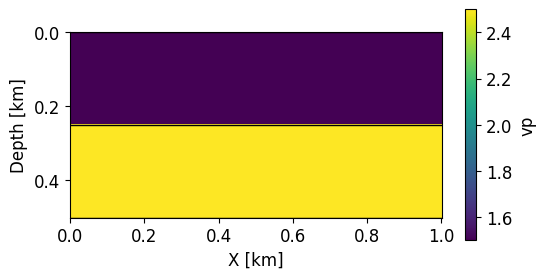

In [2]:
model = fs.LayeredModel(
    dimension=2,
    x_limits=[0.0, 1.0],
)

model.add_surface(name="top", depth=0.0)
model.add_layer(
    name="layer_1",
    properties={
        "Vp":  1.5,
        "Rho": 1.0,
    },
)
model.add_surface(name="interface", depth=0.25)
model.add_layer(
    name="layer_2",
    properties={
        "Vp": 2.5,
        "Rho": 2.2,
        "Qp": 30.0,
    },
)
model.add_surface(name="bottom", depth=0.5)

# Note: Properties are public and editable.
model.layers[0].properties["Qp"] = 15.0

sim += model
model.plot("vp", figsize=(6, 3), aspect="equal")


## Mesh And Boundary Conditions

The initial mesh is intentionally coarse. Frequency-dependent adaptivity controls element order and tells the fast solver where to refine during the solve.


In [3]:
sim += model.hex_mesh_generator([4, 4])
sim.mesh.set_adapt(elems_per_wave=1.5, order=4, f_low=5.0)

sim += fs.BoundaryCondition(
    conditions=["free"],
    boundaries=["z_min"],
)
sim += fs.BoundaryCondition(
    conditions=["pml"],
    boundaries=["x_min", "x_max", "z_max"],
)


## Acquisition

Coordinates are physical global coordinates by default. Dense surveys can use arrays directly; sparse surveys can be added later through `SparseSurvey` without changing the rest of the simulation setup.


In [4]:
acq = fs.Acquisition()
acq.add_sources(
    kind="scalar",
    coords=[[0.5, 0.05]],
)

hydrophone = fs.ReceiverNode(name="hydrophone")
hydrophone.add_component(name="p", field="pressure")

receiver_coords = [[x, 0.025] for x in np.linspace(0.0, 1.0, 101)]
acq.add_receiver_group(
    name="surface",
    device=hydrophone,
    coords=receiver_coords,
)
sim += acq


## Run, Inspect Job Details, And Read Traces

`site.submit(job)` returns immediately with a `RunHandle`. Use `run.wait()`, `await run`, or `site.run(job)` when blocking behavior is desired. The helper below prints the public job-status methods and plots per-task timings when timing metadata is available.

In [5]:
# config = fs.SlurmRunConfig(
#     nodes = 1,
#     queue = "skx-dev",
#     duration = "00-00:10:00",
# )
# site = fs.Stampede3Site(
#     rel_path = "scratch/ex_01/", 
#     run_config = config
# )
site = fs.LocalSite(shutdown_on_completion=True, verbose=True)

job = fs.TimeDomainJob(
    name="time",
    simulation=sim,
    f_min=0.0,
    f_max=45.0,
    T_max=1.0,
)
result = site.submit(job).wait() 
traces = result.traces(upscale=4)


2026-05-13 22:11:38,279 [INFO] frequensolve.orchestrator.sites.local:228 - Skipping job time; fingerprint matches and expected trace outputs exist.
2026-05-13 22:11:38,390 [INFO] frequensolve.orchestrator.sites.local:382 - LocalSite: skipped - Run is current


LocalSite: skipped - Run is current


## Plot A Gather

`TraceDataset` exposes groups, components, sources, frequency-domain data, and time-domain data without the old record database layer.


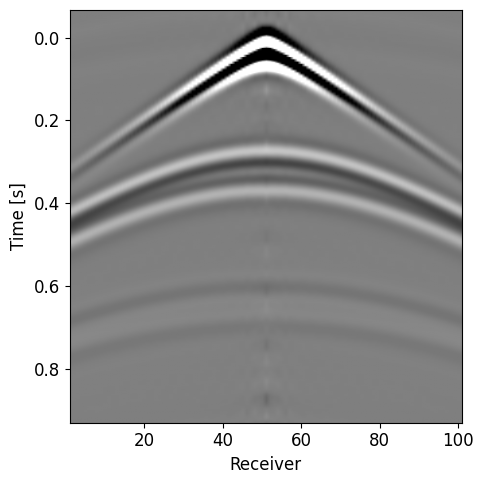

In [6]:
wavelet = fs.RickerWavelet(f=15.0)

group     = traces.groups[0]
component = traces.components(group)[0]
source    = traces.sources(group)[0]

gather = traces.td(group, component, source, wavelet, upscale=4)
fig, ax = fs.plot_gather(
    gather,
    A=2.0 * np.std(np.abs(gather)),
    cmap="gray",
)


## Single-Frequency Jobs

Frequency-domain jobs use the same project, simulation, site, and trace-reading flow.


In [7]:
fd_job = fs.FrequencyDomainJob(
    name="freq_10hz",
    simulation=sim,
    f_list=[20.0],
    outputs=[
        fs.ParaviewOutput(
            name="pv_coarse",
            fields=["pressure"],
            properties=["vp", "rho", "Subdomain"],
            show_pml=False,
            upscale=0,
            order=1,
        ),
        fs.ParaviewOutput(
            name="pv_fine",
            fields=["pressure"],
            properties=["vp", "rho", "Subdomain"],
            show_pml=True,
            upscale=1,
            order=2,
        ),
    ],
)

fd_run = site.submit(fd_job)
fd_result = fd_run.wait()


2026-05-13 22:11:38,552 [INFO] frequensolve.orchestrator.sites.local:228 - Skipping job freq_10hz; fingerprint matches and expected trace outputs exist.
2026-05-13 22:11:38,575 [INFO] frequensolve.orchestrator.sites.local:382 - LocalSite: skipped - Run is current


LocalSite: skipped - Run is current


## Plot Frequency-Domain VTU Output


In [ ]:
vtu_coarse = fd_result.output_files(base = "pv_coarse", suffix=".vtu")[0]
vtu_fine   = fd_result.output_files(base = "pv_fine",   suffix=".vtu")[0]

fs.plot_vtu(
    vtu_coarse,
    field="vp",
    cmap="Blues",
    show_edges=True,
    scalar_bar=True,
    window_size=(1000, 600),
)

fs.plot_vtu(
    vtu_fine,
    field="pressure",
    part="im",
    cmap="RdGy",
    vmin=-10.0,
    vmax=10.0,
    scalar_bar=True,
    window_size=(1000, 600),
)


Widget(value='<iframe src="http://localhost:63690/index.html?ui=P_0x13b9d04f0_0&reconnect=auto" class="pyvista…

Widget(value='<iframe src="http://localhost:63690/index.html?ui=P_0x14a5510f0_1&reconnect=auto" class="pyvista…

: 